# T31 — Plate Mantle Reference Frame Uncertainty

Where a tectonic plate or continent is located *relative to the mantle* in deep time is not a single answer but a **range**.
The relative motions between plates are tightly constrained by seafloor and geological data, but the
**absolute** motion — the entire plate system's position and spin relative to the deep mantle — is far
less certain. This notebook visualises that uncertainty for the Zahirovic et al. (2022) model
(0–410 Ma) using three alternative mantle reference frames produced by the recently updated and streamlined 
EarthByte [**optAPM**](https://github.com/EarthByte/optAPM) absolute-plate-motion optimisation.

## The optimisation, in brief

optAPM keeps a model's relative plate motions fixed and re-derives only the **absolute** frame. At each
5 Myr step it perturbs the absolute rotation of a reference plate (Africa, 701) and scores each
candidate against geodynamic penalties — lithospheric **net rotation (NR)**, **trench migration**
(trench-normal rollback velocities), continental **plate velocities**, and **hotspot trails**
(0–80 Ma) — then keeps the rotation that minimises their weighted sum. The dominant control is the
net-rotation term, so the defensible uncertainty envelope is expressed as **end-members in the net
rotation**:

- **No-net rotation (NNR)** — the lithosphere has zero net rotation (the zero-NR end-member).
- **Optimised, mean NR** (`best`) — NR bounded to 0.08–0.20 deg/Myr: non-zero (as suggested by
  mantle-flow models) but below the preferred geodynamic limit. This is the preferred frame.
- **Optimised, maximum NR** (`nr_max`) — the NR bound relaxed to 0.30 deg/Myr and the NR weight
  halved, giving the largest geodynamically-defensible net rotation (the high-NR end-member).

Together these three frames bracket the plausible range of absolute plate motion.

## What this notebook shows

1. **Three synthetic apparent-polar-wander paths** (0–410 Ma) — one per frame — on a polar map.
2. **Reconstruction snapshots** at 100, 200, 300 and 400 Ma, with the preferred frame as a filled-grey
   base and the two end-member frames overlain as thin coloured outlines (T30 style).
3. **Model diagnostics** through time — net rotation and trench-normal migration — for all three
   frames, reproducing the statistics from optAPM's `model_diagnostics.py`.

## Learning objectives

- Understand why the absolute (mantle) reference frame is uncertain and how optAPM brackets it.
- Reconstruct one model under several full rotation models and layer them legibly (filled base + line
  overlays) on a pyGMT map.
- Build a synthetic apparent-polar-wander path from a rotation model.
- Read and plot the optAPM net-rotation and trench-migration diagnostics.

## Prerequisites and runtime

- `gplately`, `pygmt`, `pygplates`, `pandas`, `matplotlib`.
- Self-contained: the optAPM outputs used here ship with the tutorial in
  `data/optAPM_reference_frames/` — three rotation files (NNR, mean-NR, max-NR) and their three
  diagnostics CSVs, produced by the [optAPM workflow](https://github.com/EarthByte/optAPM) for the
  Zahirovic 2022 model. No optAPM installation or re-run is needed.
- Runtime: ~1–2 minutes (the Zahirovic 2022 geometries are downloaded once via the Plate Model Manager).

In [1]:
# Defensive cwd fix (T30 convention): if launched from Notebooks/, step up so any
# relative "data/..." paths resolve. Idempotent.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

import os
import sys
import numpy as np
import pandas as pd
import pygplates
import pygmt
import gplately
from plate_model_manager import PlateModelManager

for mod in (np, pd, pygplates, pygmt, gplately):
    print(f"{mod.__name__:20s} {getattr(mod, '__version__', 'n/a')}")

# Plot styling: legible fonts for teaching figures (GMT defaults are too small).
pygmt.config(FONT_TITLE="18p,Helvetica-Bold,black",
             FONT_LABEL="14p,Helvetica,black",
             FONT_ANNOT_PRIMARY="12p,Helvetica,black")

numpy                2.3.2
pandas               2.2.3
pygplates            1.0.0
pygmt                v0.18.0
gplately             2.0.0.post19+git.2cce7bb3


## Configuration

User-tunable choices — the reference-frame files, snapshot ages and colour scheme. Everything points at
the bundled `data/optAPM_reference_frames/` folder, so no external paths are needed.

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME = "Zahirovic2022"   # PMM model providing the geometries (coastlines, topologies, static polygons)

# optAPM reference-frame outputs shipped with this tutorial.
DATA_DIR = "data/optAPM_reference_frames"

REF_PLATE       = 701                    # reference plate for the synthetic APWP (Africa)
RECON_AGES      = [100, 200, 300, 400]   # Ma — reconstruction snapshots
APWP_AGES       = list(range(0, 411, 5)) # Ma — synthetic APWP sampling
APWP_LABEL_AGES = [100, 200, 300, 400]   # Ma — labelled points along each APWP

# The three reference frames: label -> complete rotation model (each anchored at plate 000).
ROT_FILES = {
    "No-net rotation (NNR)": os.path.join(DATA_DIR, "Zahirovic2022_NNR.rot"),
    "Optimised, mean NR":    os.path.join(DATA_DIR, "Zahirovic2022_optimised_mean_NR.rot"),
    "Optimised, max NR":     os.path.join(DATA_DIR, "Zahirovic2022_optimised_max_NR.rot"),
}
# Pre-computed optAPM diagnostics (from model_diagnostics.py) for each frame.
DIAG_CSVS = {
    "No-net rotation (NNR)": os.path.join(DATA_DIR, "Zahirovic2022_NNR_diagnostics.csv"),
    "Optimised, mean NR":    os.path.join(DATA_DIR, "Zahirovic2022_optimised_mean_NR_diagnostics.csv"),
    "Optimised, max NR":     os.path.join(DATA_DIR, "Zahirovic2022_optimised_max_NR_diagnostics.csv"),
}
# Consistent colour scheme across ALL figures (maps, APWP and diagnostics). These are the muted
# matplotlib "tab" colours as hex (tab:red = #d62728, tab:blue = #1f77b4), accepted by both pyGMT and
# matplotlib, so the same three colours identify the frames everywhere.
COL = {"No-net rotation (NNR)": "#d62728", "Optimised, mean NR": "black", "Optimised, max NR": "#1f77b4"}
# In the reconstruction snapshots, this frame is the filled-grey base; the other two are line overlays.
BASE_FRAME = "Optimised, mean NR"
FILL_BASE  = "gray85"
# ============================================================================

for _label, _f in ROT_FILES.items():
    print(("  OK   " if os.path.exists(_f) else " MISSING ") + _label + ": " + _f)

  OK   No-net rotation (NNR): data/optAPM_reference_frames/Zahirovic2022_NNR.rot
  OK   Optimised, mean NR: data/optAPM_reference_frames/Zahirovic2022_optimised_mean_NR.rot
  OK   Optimised, max NR: data/optAPM_reference_frames/Zahirovic2022_optimised_max_NR.rot


In [3]:
# Geometries (coastlines, topologies, static polygons) come from the published Z22 model via the
# Plate Model Manager; the absolute motion comes from each of our three optimised rotation files
# (each anchored at plate 000). One reconstruction tree per frame.
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

recon, gplot = {}, {}
for label, rot_file in ROT_FILES.items():
    recon[label] = gplately.PlateReconstruction(
        rotation_model=pygplates.RotationModel(rot_file),
        topology_features=model.get_topologies(),
        static_polygons=model.get_static_polygons(),
    )
    gplot[label] = gplately.PlotTopologies(recon[label], coastlines=model.get_coastlines())
engine = gplately.PygmtPlotEngine()
print("reconstruction trees ready:", list(recon))

reconstruction trees ready: ['No-net rotation (NNR)', 'Optimised, mean NR', 'Optimised, max NR']


## 1. Three synthetic apparent polar wander (APW) paths

An **apparent polar wander path** is the track the spin axis (geographic pole) appears to trace when
you hold a continent fixed and let the pole move around it. This is the historical, pre-plate-tectonics
picture: the poles were imagined to wander while the continents stayed put. In reality it is the
opposite — the continent moves relative to the (fixed) mantle and spin axis — but the APW path is a
compact, frame-revealing summary of that motion.

Here each path is the position, back through 0–410 Ma, of a point pinned to the North Pole and viewed
in the present-day frame of fixed Africa (plate 701): `pole(t) = R(701→000, t)⁻¹ · (90°N)`. Because the
three reference frames give Africa three different absolute motions, they trace three different APW
paths. All three converge at the present-day pole (0 Ma, gold star) and **fan apart with age** — that
fan *is* the mantle-frame uncertainty.

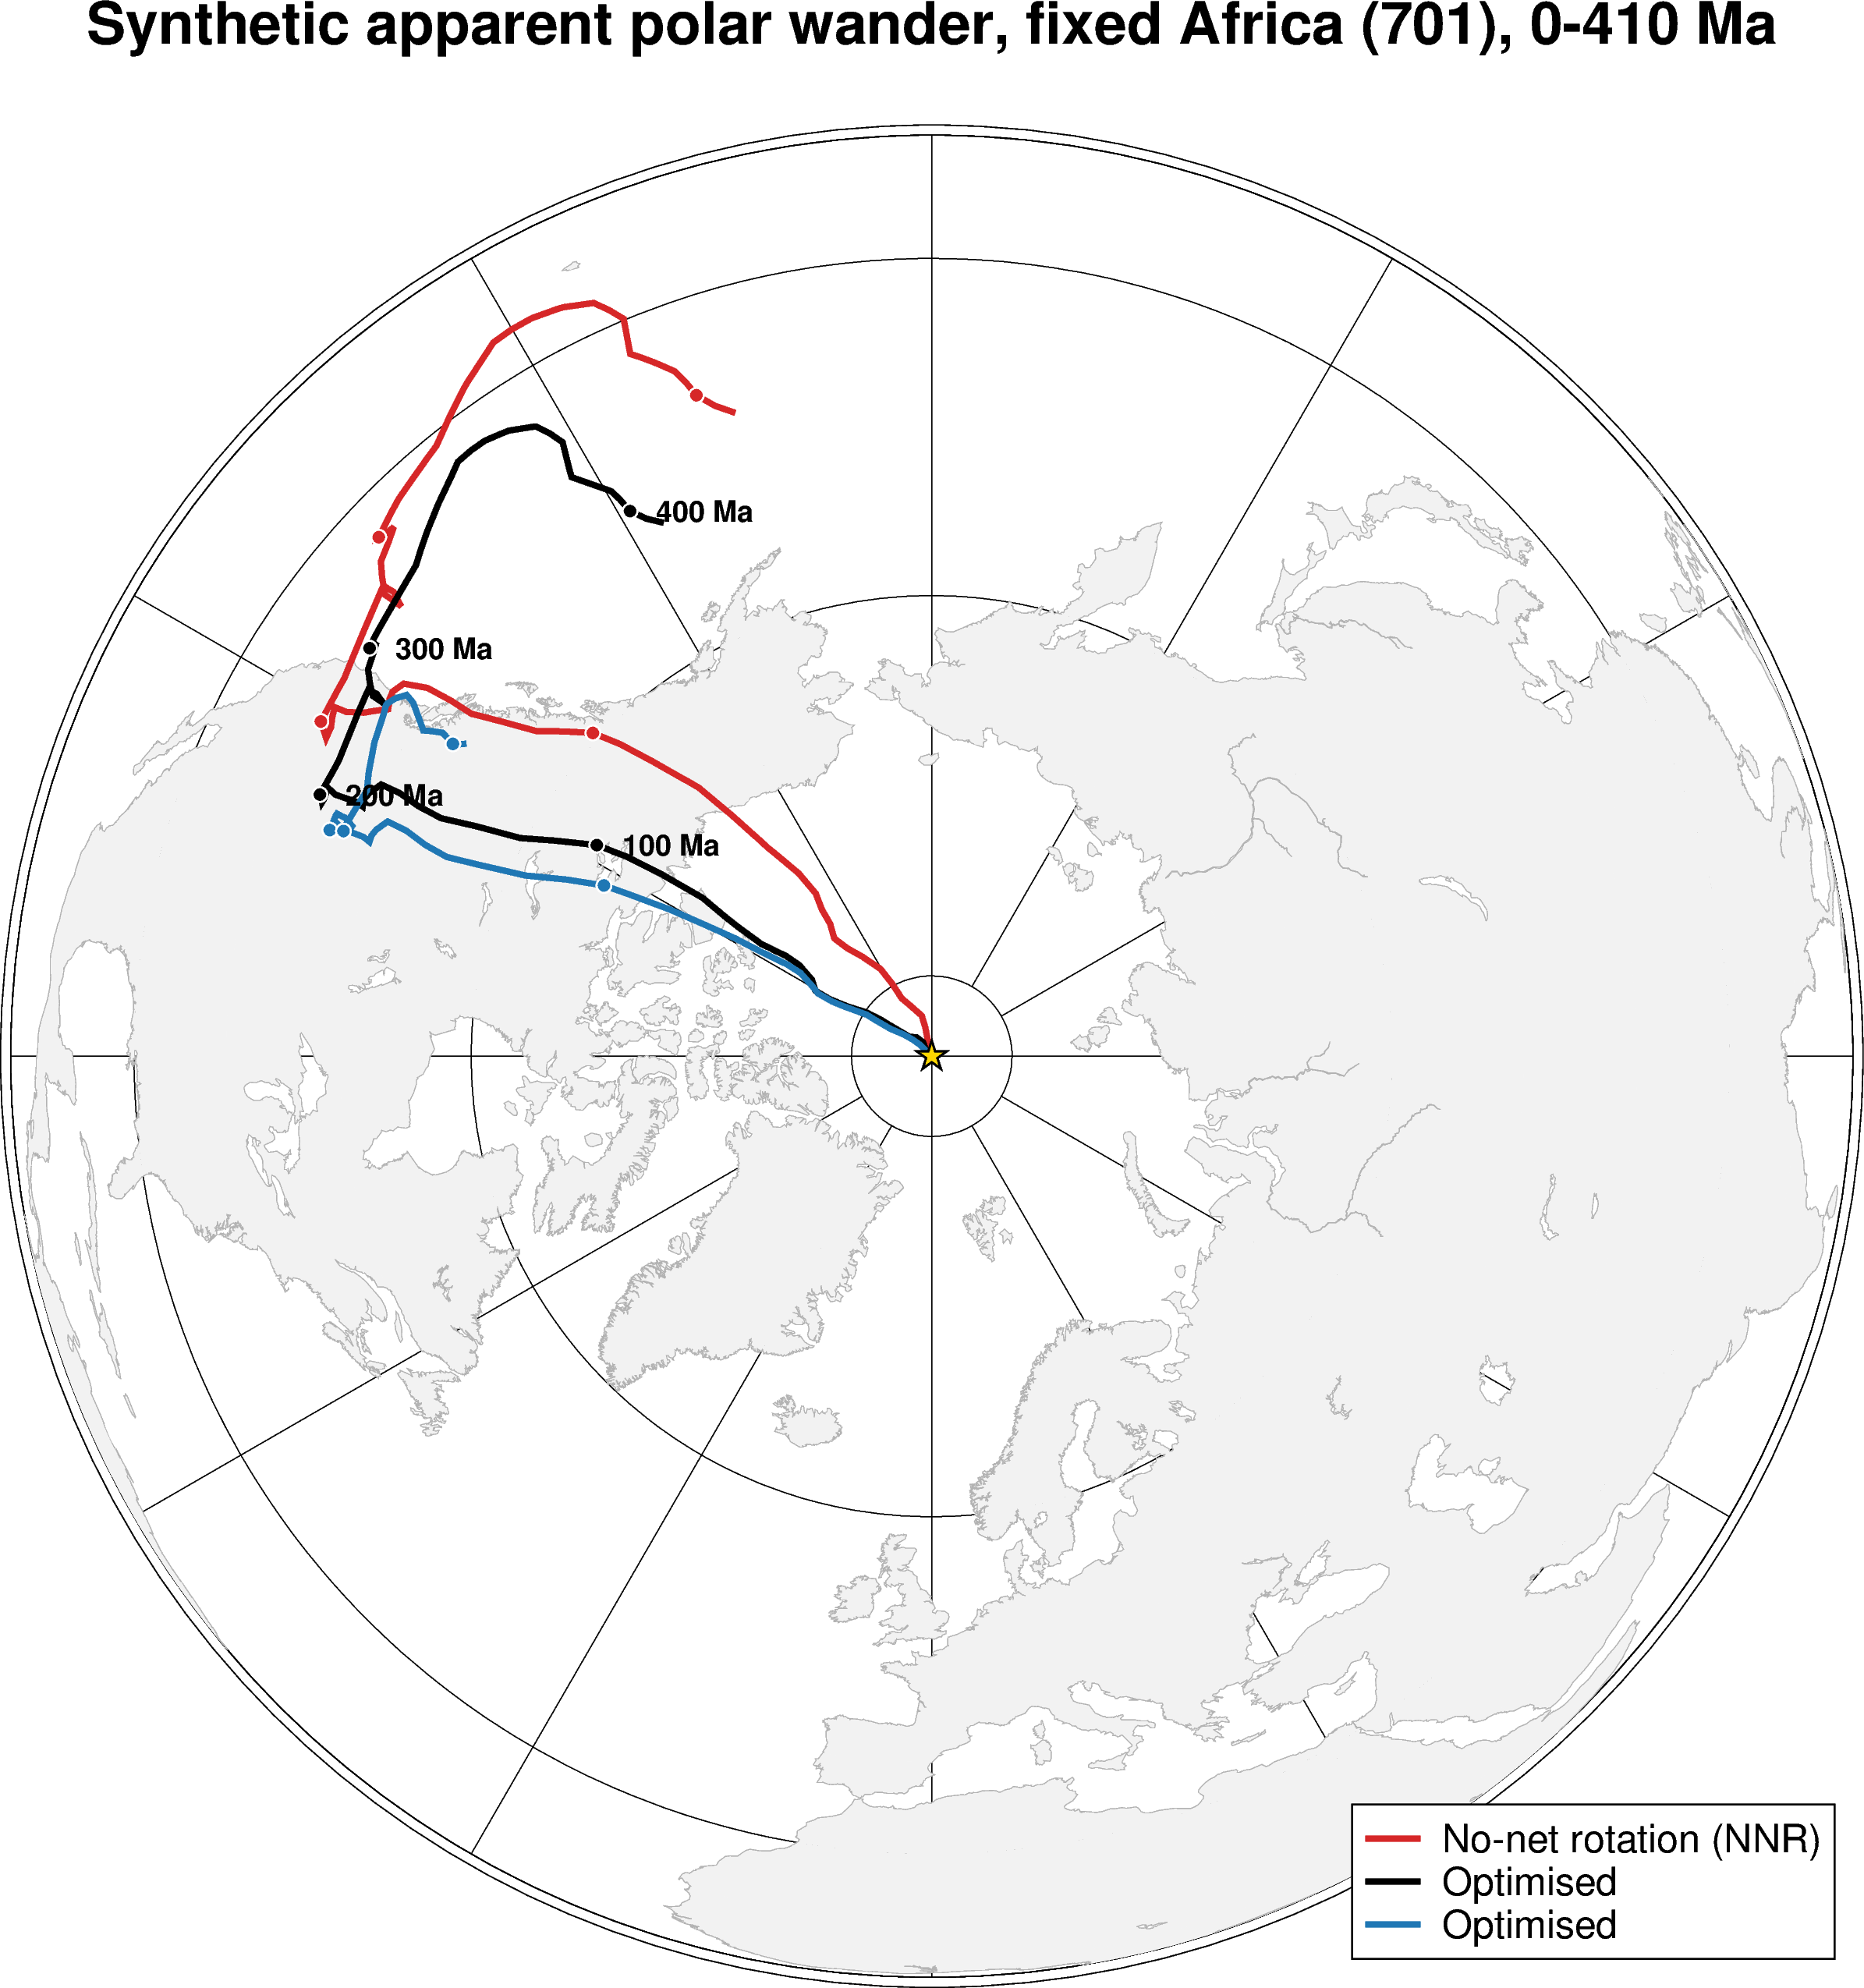

In [4]:
# Synthetic APWP: the spin axis viewed in the fixed-Africa frame, for each reference frame.
NORTH_POLE = pygplates.PointOnSphere(90, 0)

apwp = {}
for label, rot_file in ROT_FILES.items():
    rm = pygplates.RotationModel(rot_file)
    lons, lats = [], []
    for t in APWP_AGES:
        plat, plon = (rm.get_rotation(float(t), REF_PLATE).get_inverse() * NORTH_POLE).to_lat_lon()
        lons.append(plon)
        lats.append(plat)
    apwp[label] = (np.array(lons), np.array(lats))

fig = pygmt.Figure()
fig.basemap(region="g", projection="G0/90/20c",
            frame=["g30", "+tSynthetic apparent polar wander, fixed Africa (701), 0-410 Ma"])
fig.coast(land="gray95", shorelines="0.2p,gray70", area_thresh=5000)

for label, (lons, lats) in apwp.items():
    fig.plot(x=lons, y=lats, pen=f"1.8p,{COL[label]}", label=label)
    for a in APWP_LABEL_AGES:
        i = APWP_AGES.index(a)
        fig.plot(x=[lons[i]], y=[lats[i]], style="c0.16c", fill=COL[label], pen="0.5p,white")

# Age labels along the preferred (mean NR) path, and the present-day pole.
_lons, _lats = apwp[BASE_FRAME]
for a in APWP_LABEL_AGES:
    i = APWP_AGES.index(a)
    fig.text(x=_lons[i], y=_lats[i], text=f"{a} Ma", justify="ML",
             offset="0.28c/0c", font="9p,Helvetica-Bold,black")
fig.plot(x=[0], y=[90], style="a0.34c", fill="gold", pen="0.6p,black")

fig.legend(position="JBR+jBR+o0.2c", box="+gwhite+p0.5p")
fig.show(width=700)

## 2. Reconstruction snapshots under the three frames

The same continental geometry reconstructed under each frame, at 100, 200, 300 and 400 Ma. Following
the T30 convention, the **preferred frame (mean NR)** is drawn as a filled-grey base and the two
end-members are overlain as thin outlines — **red = no-net rotation**, **blue = maximum NR**. Where the
red and blue outlines depart from the grey land, that gap is the absolute-frame uncertainty at that
time. Latitudinal offsets are the most meaningful (paleolatitude is what these constraints most
directly control); some longitudinal offset reflects each frame's longitude freedom.

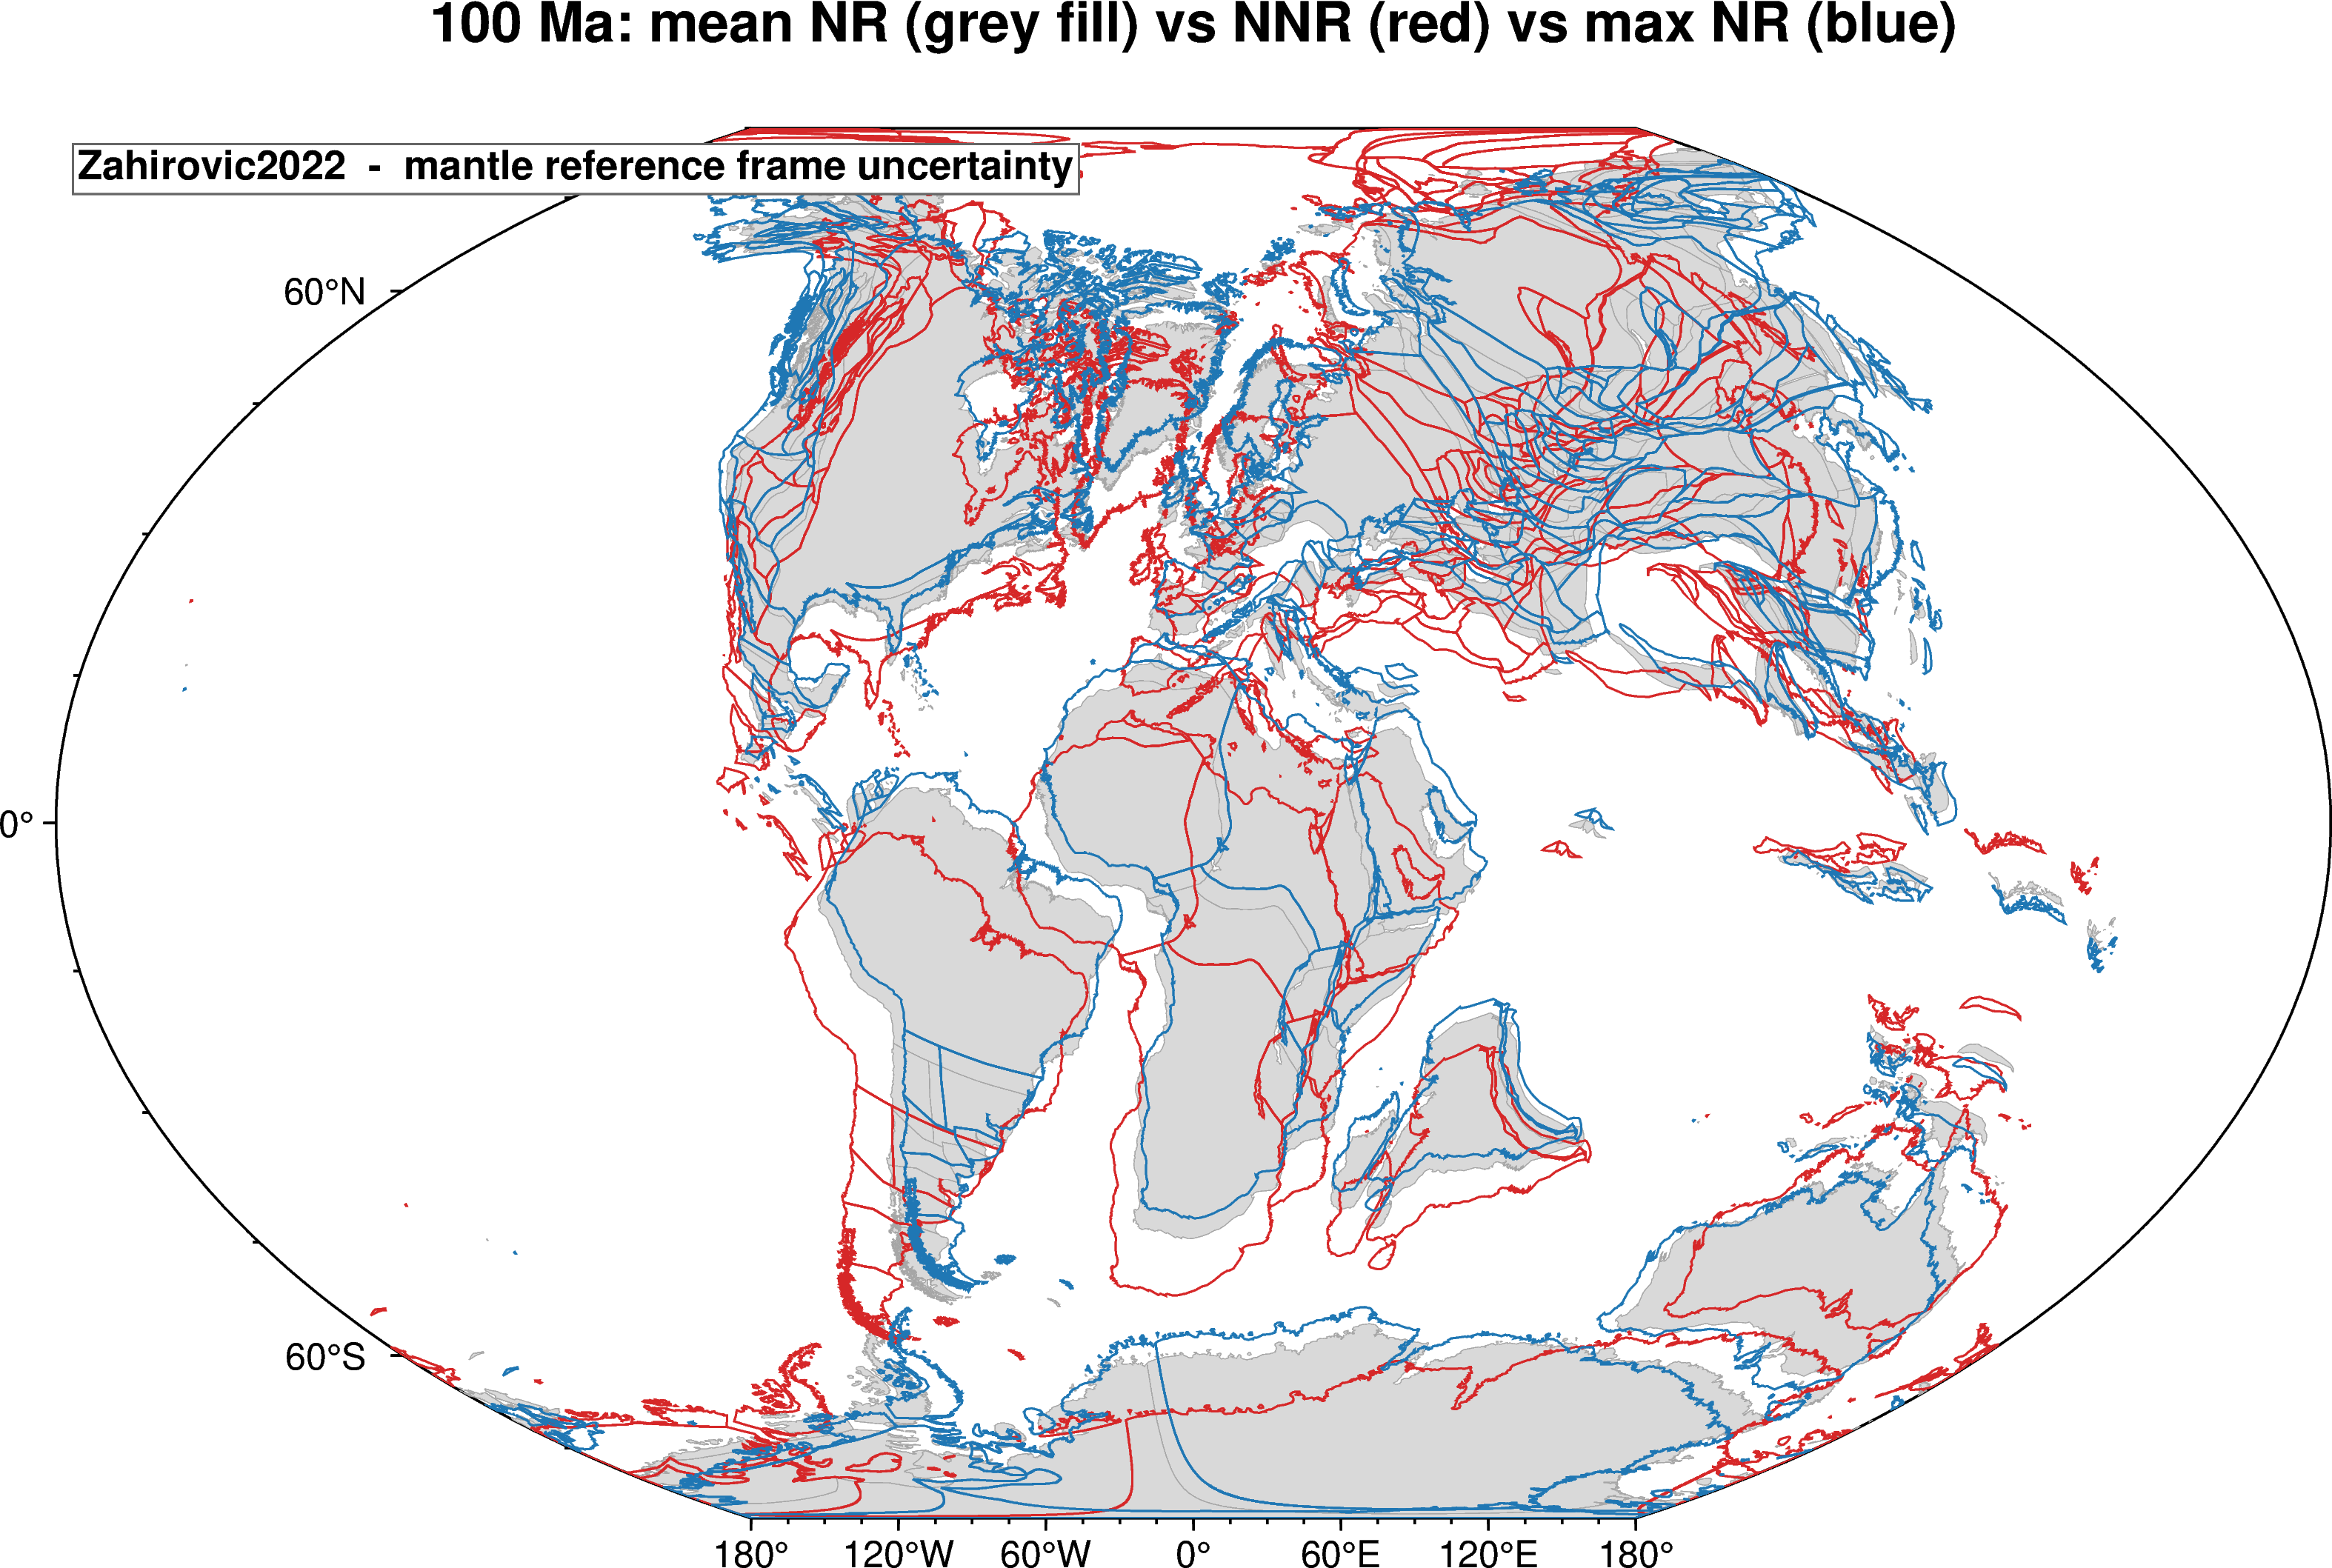

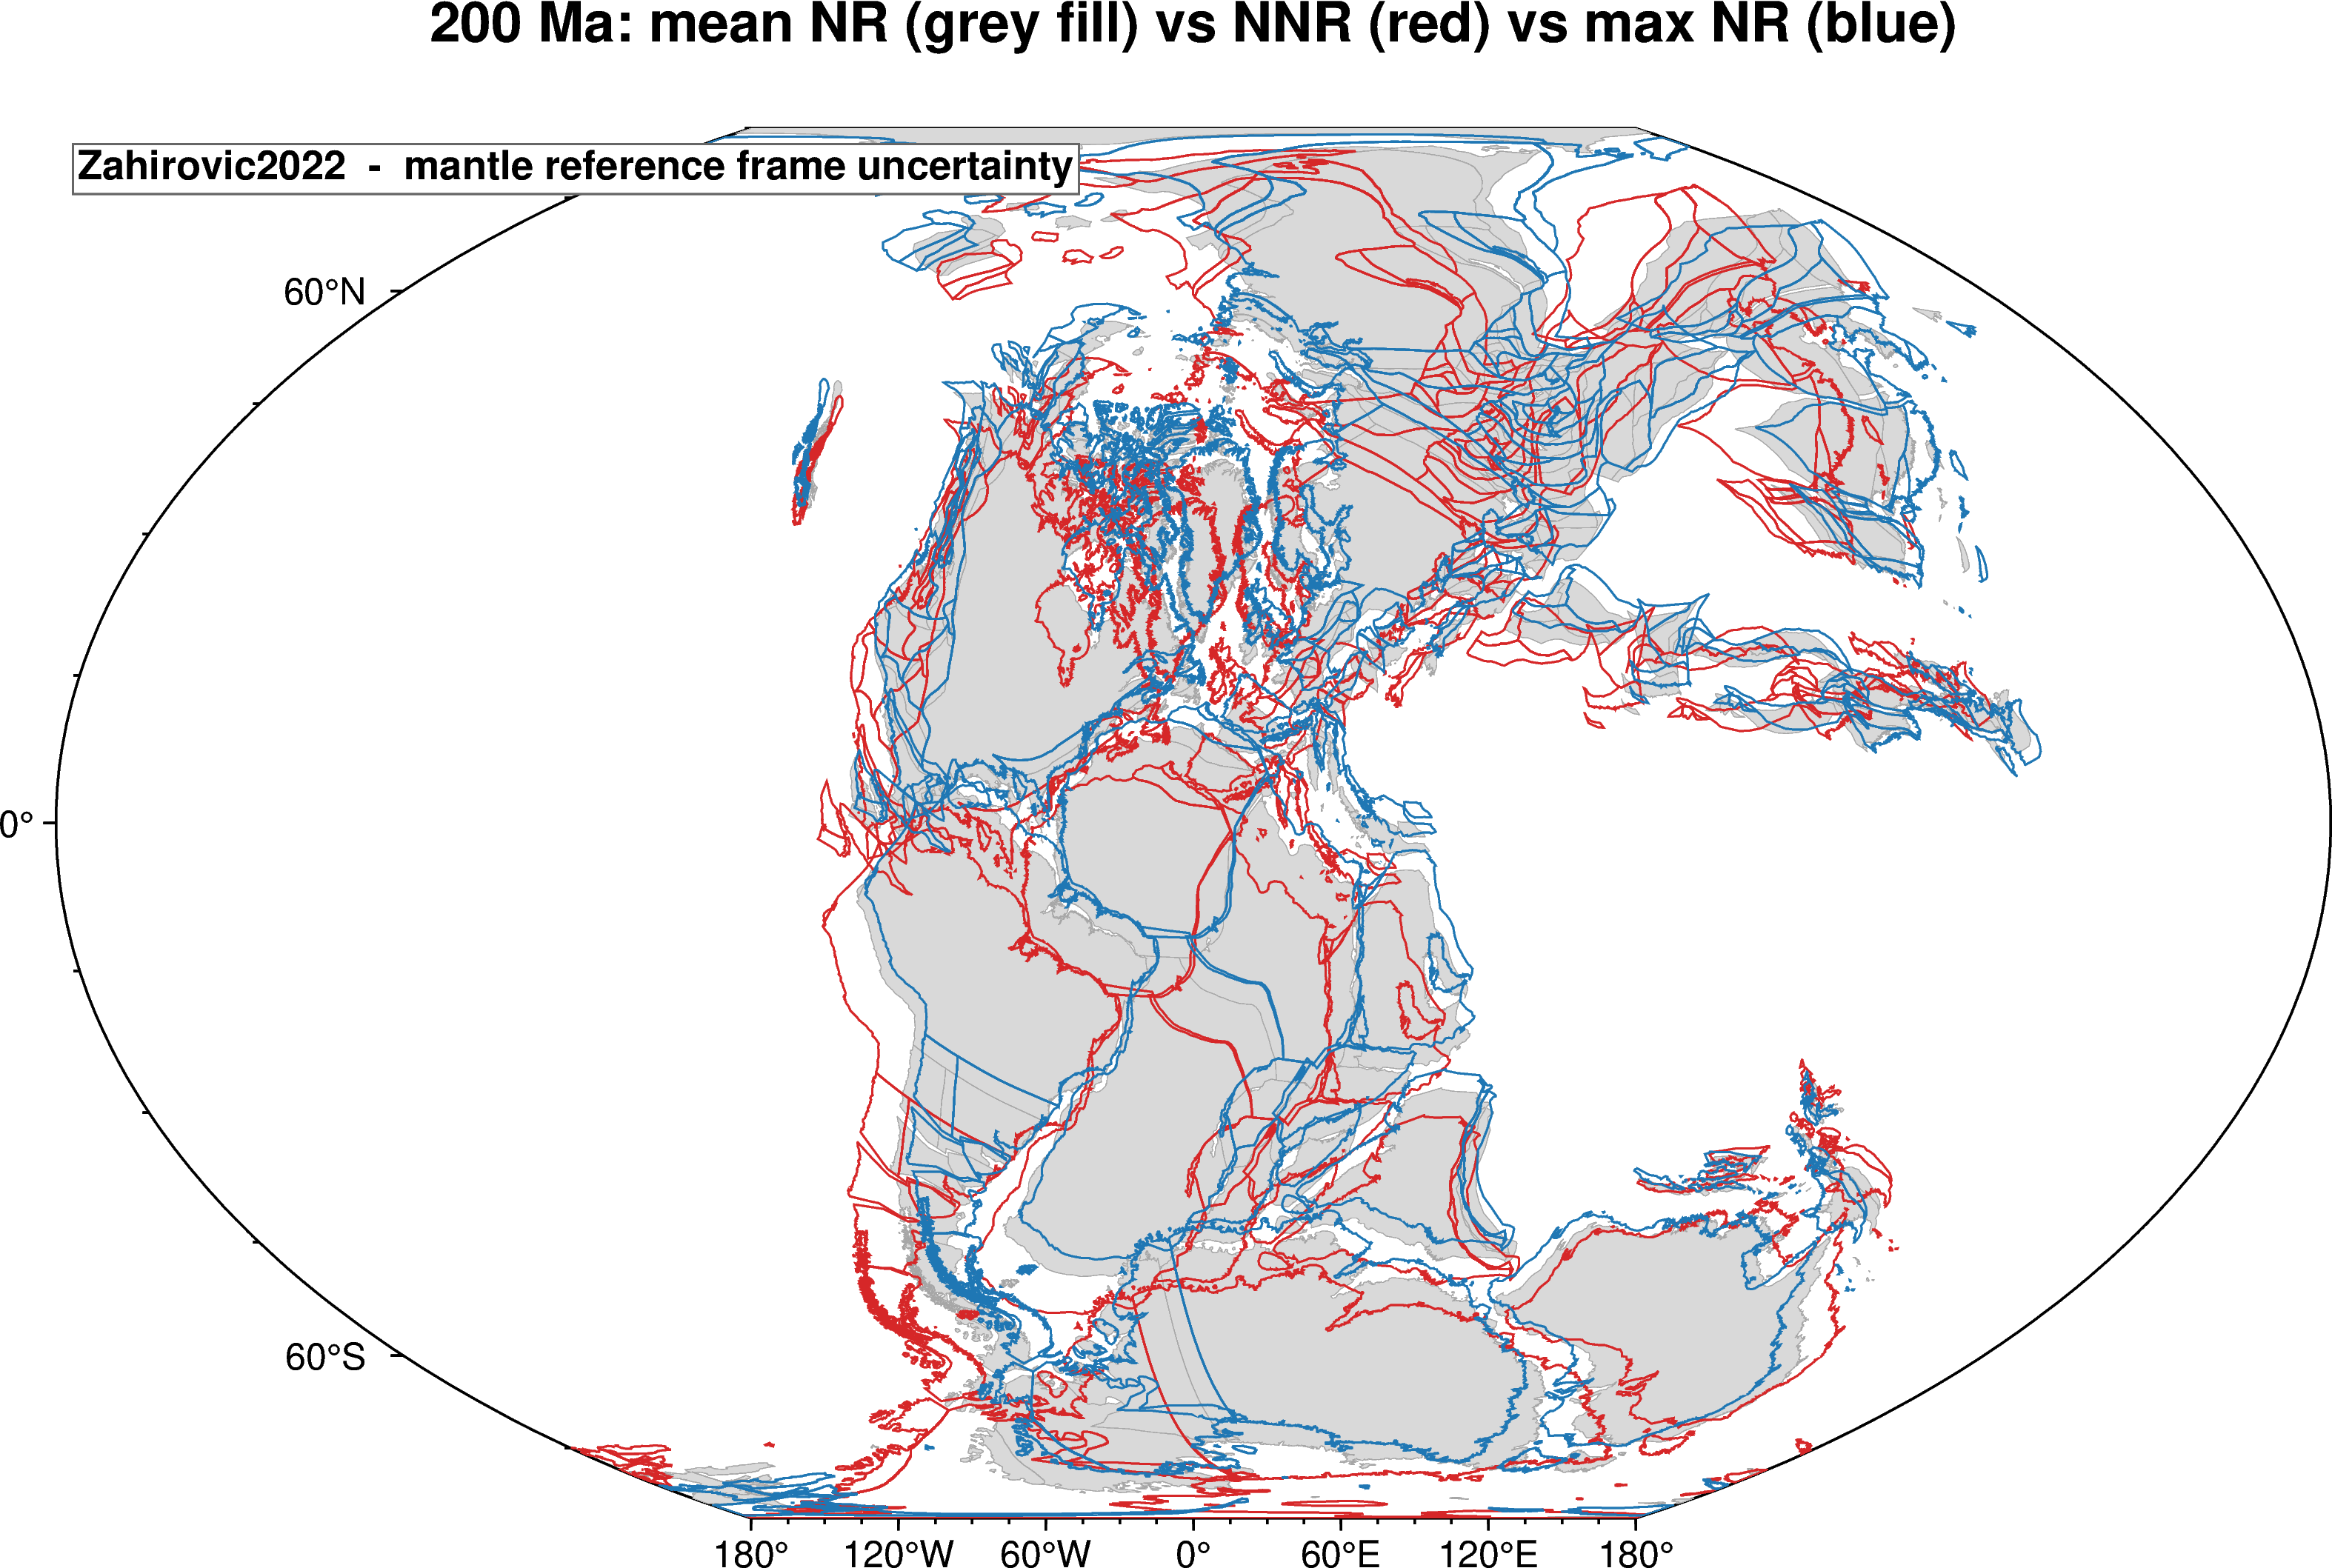

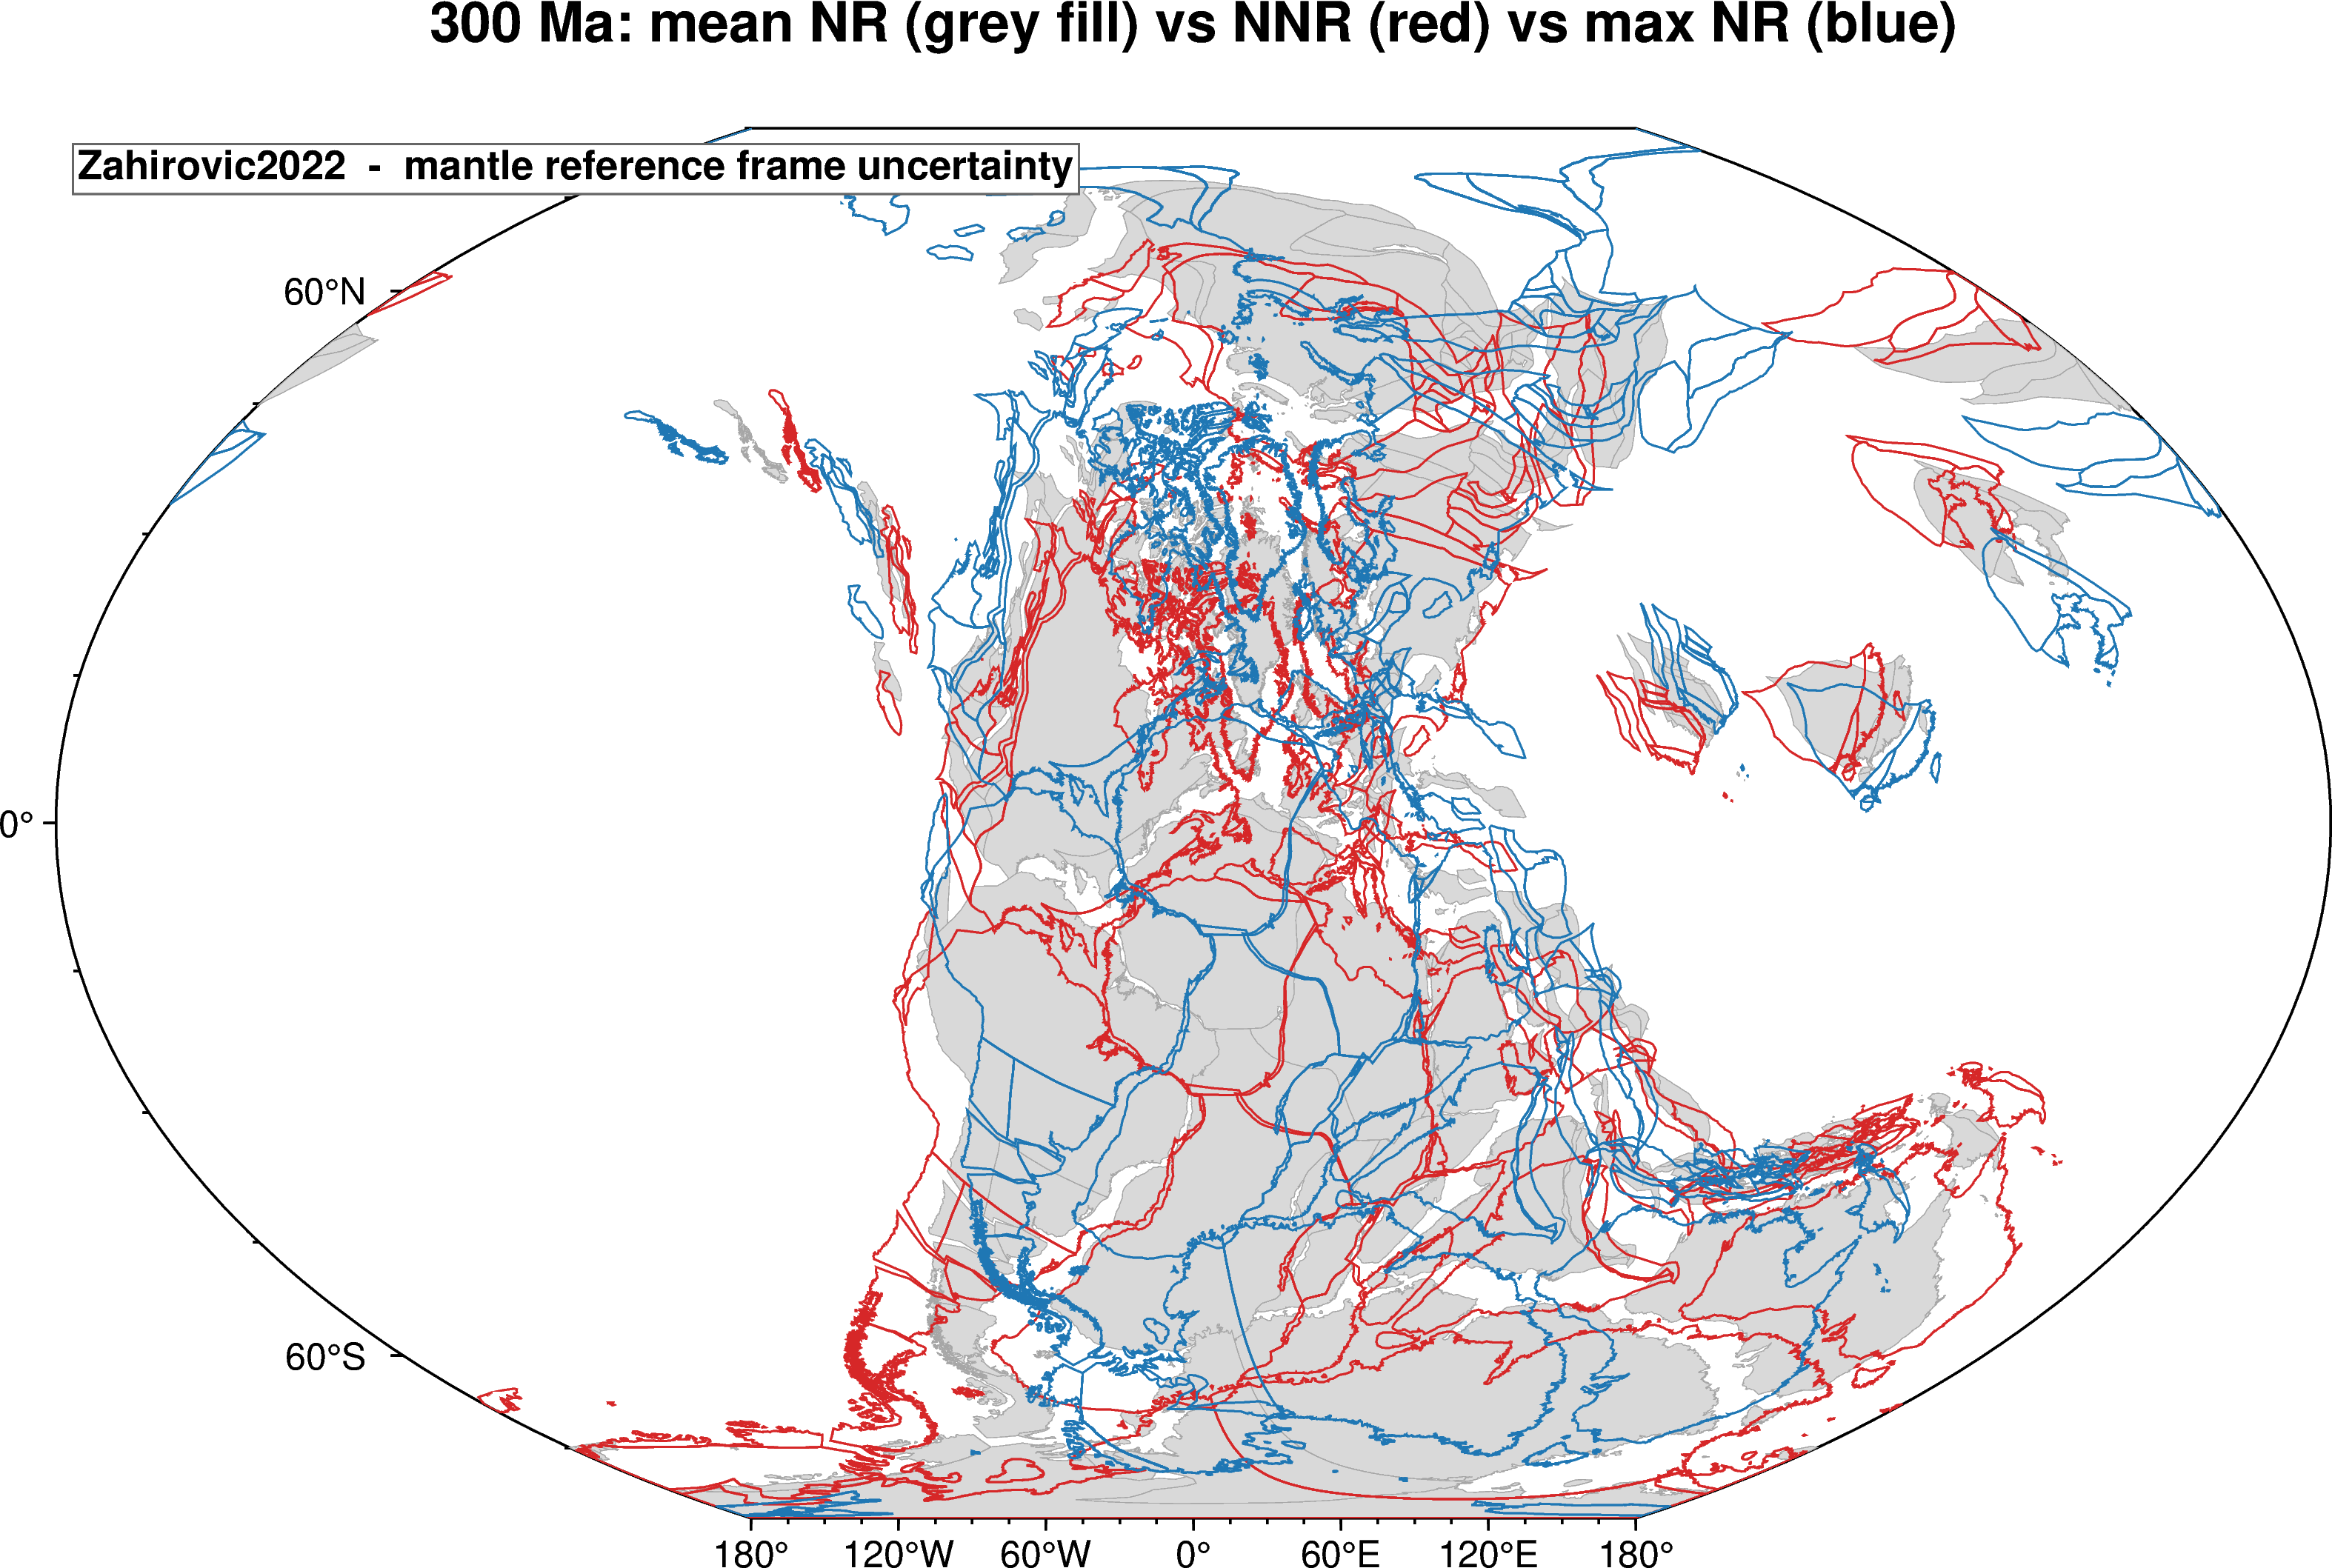

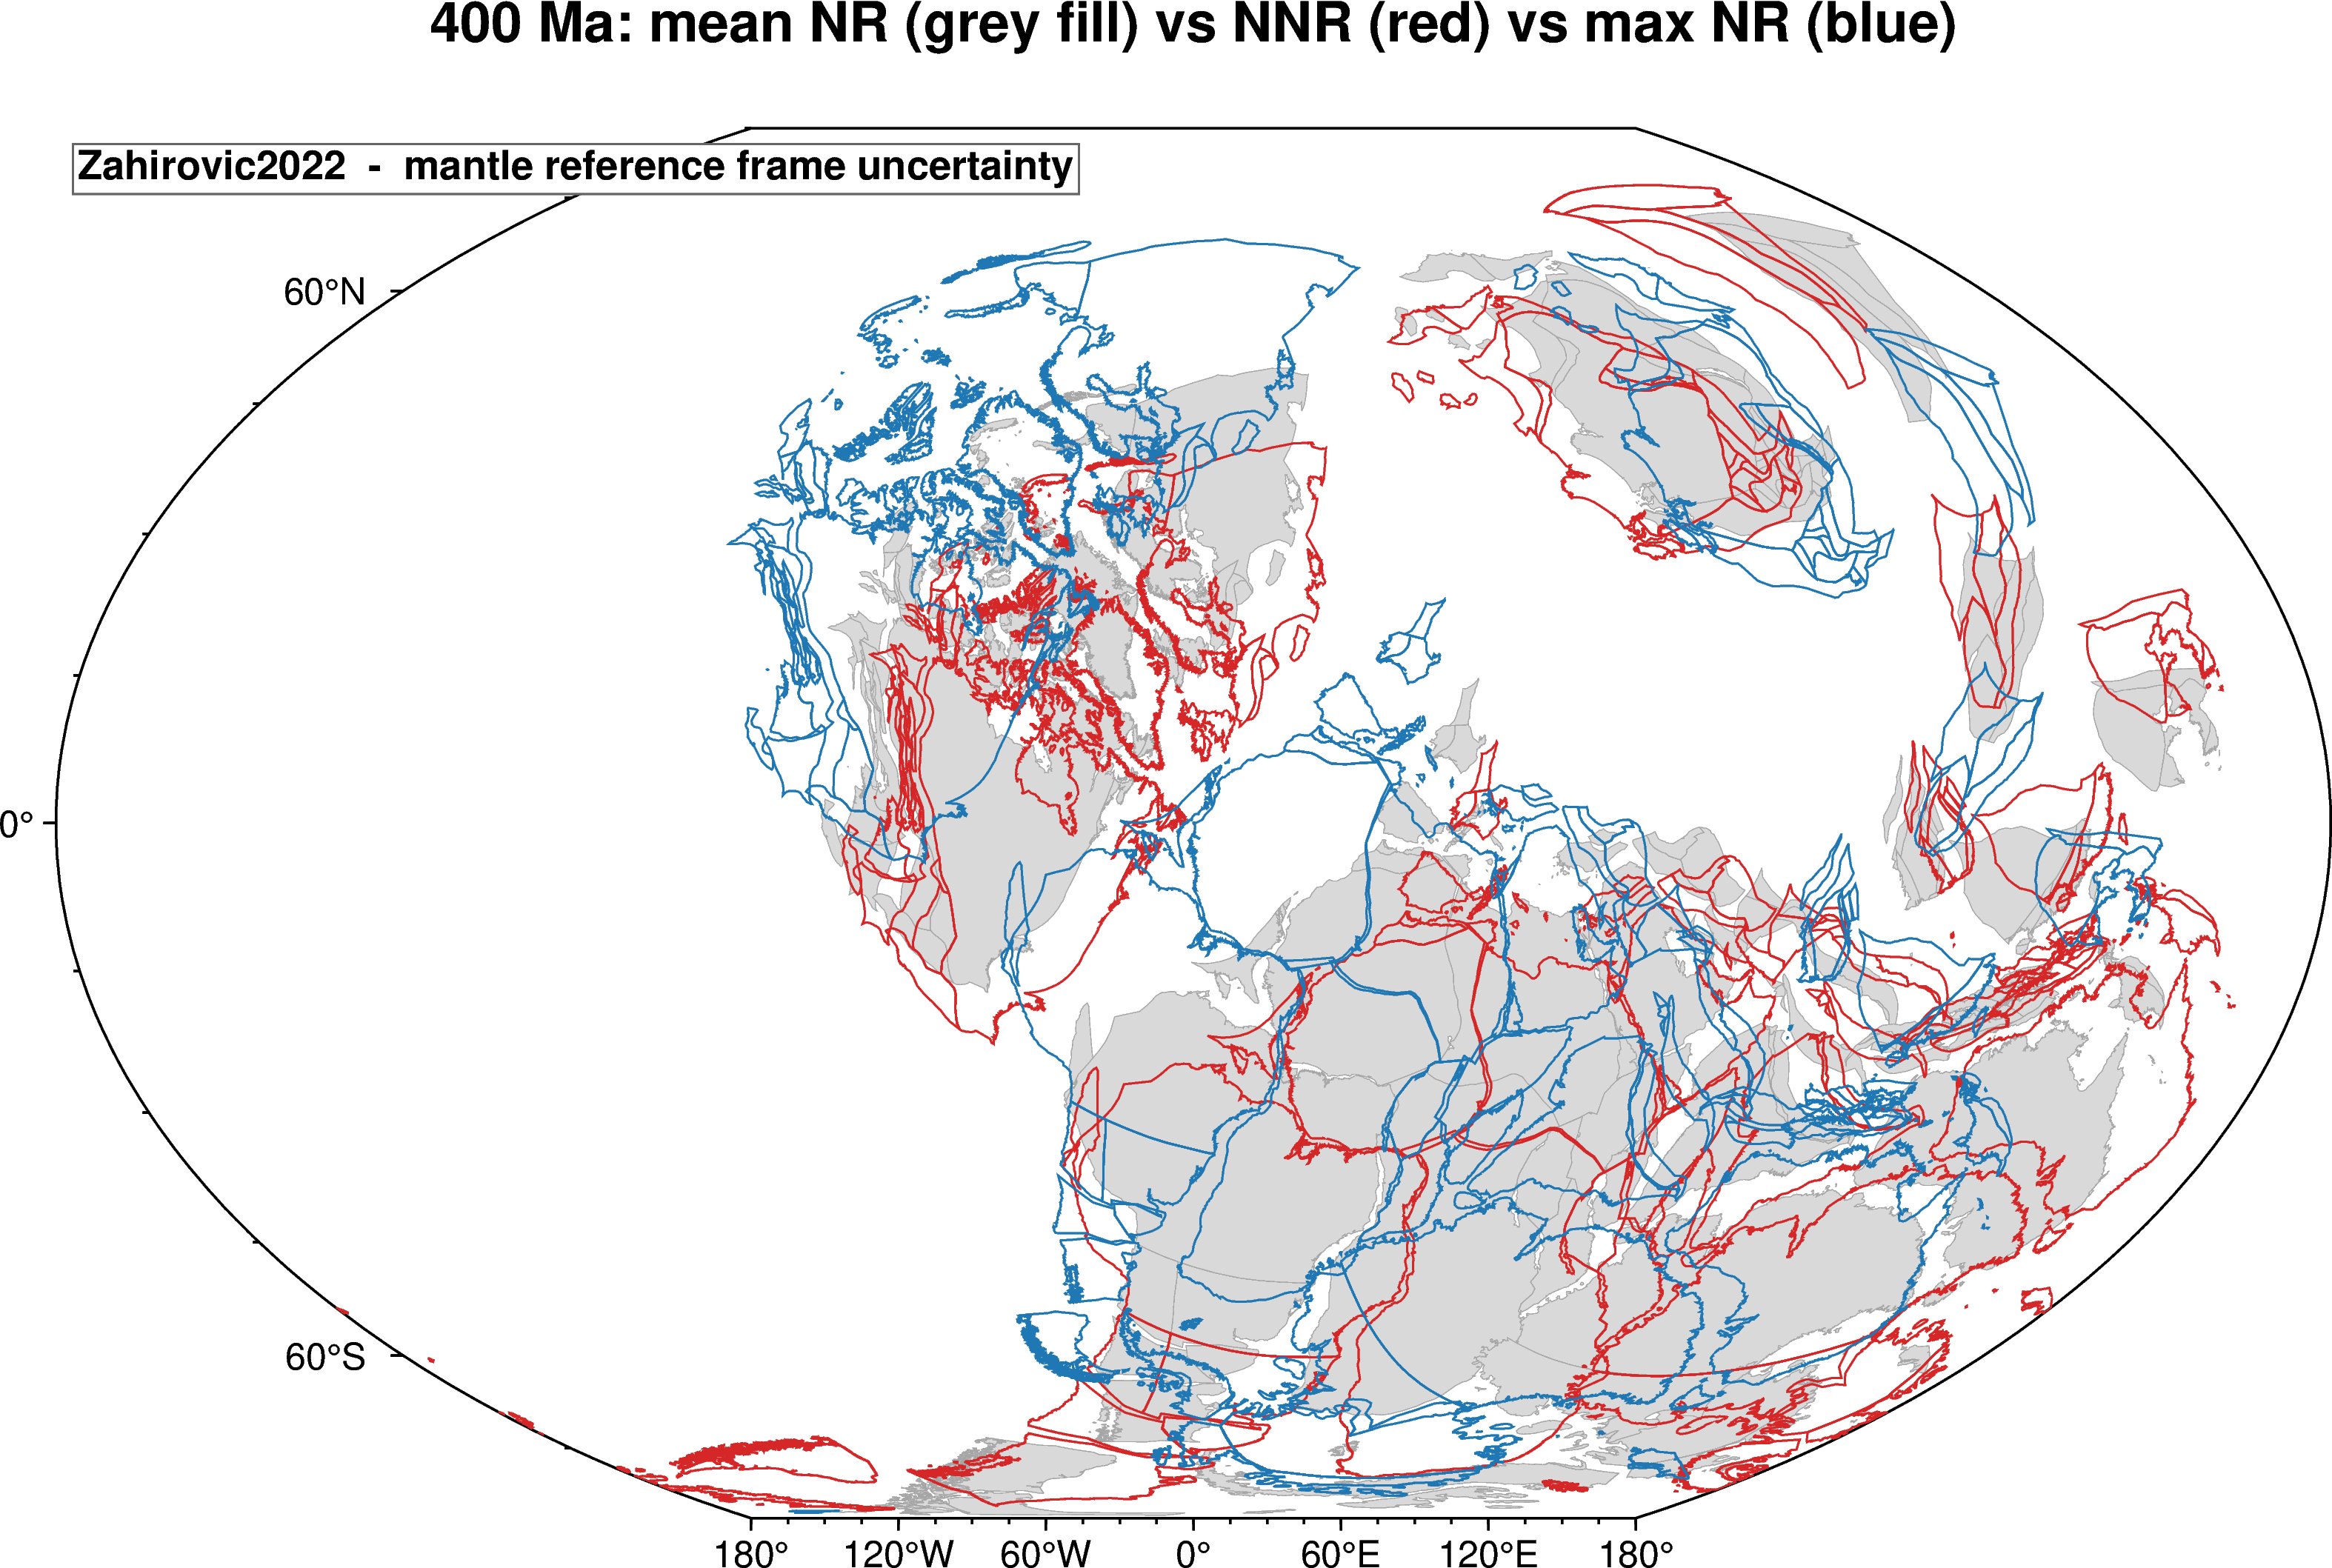

In [5]:
def plot_frame_overlays(fig, age):
    # Filled-grey base = preferred frame.
    gplot[BASE_FRAME].time = float(age)
    engine.plot_geo_data_frame(fig, gplot[BASE_FRAME].get_coastlines(),
                               fill=FILL_BASE, pen="0.2p,gray65")
    # Thin line overlays = the two end-member frames.
    for label in ROT_FILES:
        if label == BASE_FRAME:
            continue
        gplot[label].time = float(age)
        engine.plot_geo_data_frame(fig, gplot[label].get_coastlines(),
                                   pen=f"0.6p,{COL[label]}")

for age in RECON_AGES:
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="R0/26c",
                frame=["af", f"+t{age} Ma: mean NR (grey fill) vs NNR (red) vs max NR (blue)"])
    plot_frame_overlays(fig, age)
    fig.text(text=f"{MODEL_NAME}  -  mantle reference frame uncertainty",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="13p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    fig.show(width=1000)

## 3. Model diagnostics through time

optAPM's `model_diagnostics.py` summarises each frame at every timestep: lithospheric **net rotation**
(median ± MAD of the rate within each interval) and **trench-normal migration** (mean ± MAD across all
subduction segments, plus the % of segments retreating). The pre-computed statistics ship with this
tutorial (`data/optAPM_reference_frames/*_diagnostics.csv`); the cells below load and plot them.

By construction the frames differ: net rotation is ~0 for NNR, moderate for the mean-NR frame (held
within the 0.08–0.20 deg/Myr band), and highest for the max-NR frame, which presses against its
0.30 deg/Myr ceiling in deep time. The green band marks the observed present-day trench retreat rate
(Schellart et al. 2008).

In [6]:
# Load the pre-computed optAPM diagnostics shipped with the tutorial. Columns (per timestep age):
#   net_rotation_median_deg_per_myr, net_rotation_mad_deg_per_myr,
#   trench_migration_mean_mm_per_yr, trench_migration_median_mm_per_yr,
#   trench_migration_mad_mm_per_yr, percent_trenches_retreating
diag = {label: pd.read_csv(csv) for label, csv in DIAG_CSVS.items()}
for label, df in diag.items():
    print(f"{label:24s} {len(df):3d} timesteps  |  whole-run NR median "
          f"{df.net_rotation_median_deg_per_myr.median():.3f} deg/Myr,  "
          f"TM mean {df.trench_migration_mean_mm_per_yr.mean():+.1f} mm/yr")

No-net rotation (NNR)     82 timesteps  |  whole-run NR median 0.000 deg/Myr,  TM mean +8.9 mm/yr
Optimised, mean NR        82 timesteps  |  whole-run NR median 0.080 deg/Myr,  TM mean +8.7 mm/yr
Optimised, max NR         82 timesteps  |  whole-run NR median 0.165 deg/Myr,  TM mean +7.9 mm/yr


In [7]:
import matplotlib.pyplot as plt

mcol = COL  # identical palette to the maps and APWP (defined in the configuration cell)
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

# (a) Net rotation: median +/- MAD within each timestep.
ax = axes[0]
for label, df in diag.items():
    ax.plot(df.age, df.net_rotation_median_deg_per_myr, color=mcol[label], lw=1.6, label=label)
    ax.fill_between(df.age,
                    df.net_rotation_median_deg_per_myr - df.net_rotation_mad_deg_per_myr,
                    df.net_rotation_median_deg_per_myr + df.net_rotation_mad_deg_per_myr,
                    color=mcol[label], alpha=0.12)
ax.axhline(0.20, ls="--", lw=0.8, color="grey")
ax.axhline(0.26, ls=":",  lw=0.8, color="grey")
ax.text(0.99, 0.20, " 0.20 preferred upper bound", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=8, color="grey")
ax.text(0.99, 0.26, " 0.26 Conrad & Behn (2010)", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=8, color="grey")
ax.set_ylabel("Net rotation (deg/Myr)")
ax.set_title("Net rotation through time (median +/- MAD within timestep)", fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (b) Trench-normal migration: mean +/- MAD across segments.
ax = axes[1]
for label, df in diag.items():
    ax.plot(df.age, df.trench_migration_mean_mm_per_yr, color=mcol[label], lw=1.6, label=label)
    ax.fill_between(df.age,
                    df.trench_migration_mean_mm_per_yr - df.trench_migration_mad_mm_per_yr,
                    df.trench_migration_mean_mm_per_yr + df.trench_migration_mad_mm_per_yr,
                    color=mcol[label], alpha=0.10)
ax.axhline(0.0, lw=0.8, color="black")
ax.axhspan(9, 15, alpha=0.15, color="green")
ax.text(0.99, 12, " observed present-day retreat (Schellart et al. 2008)",
        transform=ax.get_yaxis_transform(), ha="right", va="center", fontsize=8, color="green")
ax.set_ylabel("Trench-normal migration\n(mm/yr; + = retreat)")
ax.set_title("Subduction zone migration through time (mean +/- MAD across segments)", fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (c) Percentage of trench segments retreating.
ax = axes[2]
for label, df in diag.items():
    ax.plot(df.age, df.percent_trenches_retreating, color=mcol[label], lw=1.6, label=label)
ax.axhline(50, ls="--", lw=0.8, color="grey")
ax.set_ylabel("Trench segments\nretreating (%)")
ax.set_xlabel("Age (Ma)")
ax.set_title("Percentage of trench segments retreating", fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[0].invert_xaxis()
fig.tight_layout()
plt.show()

## Extend this

- Re-anchor any of the three rotation files to a different reference plate and confirm the relative
  motions (and the inter-frame differences) are unchanged — the frame is just a choice of anchor.
- Add a fourth frame from a different `run_variant` (e.g. a different NR ceiling) to widen or narrow
  the envelope.
- Replace the synthetic APWP for Africa with one for another continent (change `REF_PLATE`).
- Track a single site's paleolatitude under all three frames (cf. T30) to read the uncertainty as a
  north–south band at that location.
- Swap coastlines for continental polygons, or add the plate-boundary backbone to the base frame only.

## References

- Müller, R.D., Flament, N., Cannon, J., Tetley, M.G., Williams, S.E., Cao, X., Bodur, Ö.F.,
  Zahirovic, S. & Merdith, A. (2022). A tectonic-rules-based mantle reference frame since 1 billion
  years ago. *Solid Earth* 13, 1127–1159. https://doi.org/10.5194/se-13-1127-2022
- Tetley, M.G., Williams, S.E., Gurnis, M., Flament, N. & Müller, R.D. (2019). Constraining absolute
  plate motions since the Triassic. *J. Geophys. Res. Solid Earth* 124, 7231–7258.
  https://doi.org/10.1029/2019JB017442
- Conrad, C.P. & Behn, M.D. (2010). Constraints on lithosphere net rotation and asthenospheric
  viscosity from global mantle flow models and seismic anisotropy. *Geochem. Geophys. Geosyst.* 11,
  Q05W05. https://doi.org/10.1029/2009GC002970
- Schellart, W.P., Stegman, D.R. & Freeman, J. (2008). Global trench migration velocities and slab
  migration induced upper mantle volume fluxes. *Earth-Science Reviews* 88, 118–144.
  https://doi.org/10.1016/j.earscirev.2008.01.005
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
- Mather, B.R., Müller, R.D., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S.,
  Tetley, M. & Merdith, A. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
  https://doi.org/10.1002/gdj3.185
- Tian, D. et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*.
